### *Notebook 3: Phases 1 to 4*

## *Setup and Import*

In [1]:
import sys, warnings, logging, time
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore")
logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from src.config import DATA_PROCESSED, OUTPUTS

OUTPUTS.mkdir(parents=True, exist_ok=True)

# ── Confirm Notebook 2 outputs exist before proceeding ────────────────────────
required = {
    "df_combined.parquet" : "Section 3 (Notebook 1)",
}
for fname, source in required.items():
    path = DATA_PROCESSED / fname
    if path.exists():
        print(f"{fname}: OK ({path.stat().st_size / 1024**3:.1f} GB)")
    else:
        raise FileNotFoundError(f"{fname} not found — run {source} first")

print("Notebook 2 ready")

df_combined.parquet: OK (9.8 GB)
Notebook 2 ready


## Section 5 — Phase 1: Product Embeddings (Word2Vec / Item2Vec)

**Core idea**: treat each shopping basket as a sentence and each product ID as a word. Word2Vec learns vector representations such that products frequently bought together land geometrically close in 100-dimensional space. The resulting product vectors are the foundation for every downstream step — customer vectors, dimensionality reduction, and clustering all inherit their quality.

### Why Item2Vec works here
- Co-purchase context is the strongest behavioural signal in transactional data
- Skip-gram (sg=1) predicts the context from the product — better than CBOW for rare items
- window=5 means "within the same basket" for most carts (median basket ≈ 10 items)
- min_count=3 drops products that appear in fewer than 3 baskets — too rare to embed reliably

### Pipeline steps
| Step | Output | Memory strategy |
|---|---|---|
| 5.1 Build basket sentences | `basket_sentences.parquet` | Streaming group_by — never materialises 190M rows |
| 5.2 Train Word2Vec | `models/word2vec_product.model` | Basket file loaded once (~1.7 GB Arrow), streamed per epoch |
| 5.3 Save embeddings | `product_embeddings.parquet` | ~47 MB — trivial |
| 5.4 Sanity check | stdout | Nearest-neighbour lookup, no extra data needed |

All steps are cached — re-running any cell is instant after the first run.

In [2]:
# ── Section 5 entry point — safe to run even if Sections 1–3 were skipped ─────
import sys, logging
from pathlib import Path

# Locate project root regardless of where Jupyter was launched from
_root = next(
    p for p in [Path.cwd(), Path.cwd().parent]
    if (p / "src" / "config.py").exists()
)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

from src.embeddings import (
    build_basket_sentences,
    train_word2vec,
    save_embeddings,
    sanity_check,
)
from src.config import DATA_PROCESSED, MODELS

# Re-attach df_articles if this session skipped the earlier sections
if "df_articles" not in vars():
    from src.data_loader import load_maestra_articulos
    df_articles = load_maestra_articulos()
    print(f"Loaded df_articles: {len(df_articles):,} rows")
else:
    print(f"df_articles already in session: {len(df_articles):,} rows")

print("Section 5 imports OK")

Loaded df_articles: 893,944 rows
Section 5 imports OK


### 5.1 Build Basket Sentences

Group the 190 M clean transaction lines by ticket number. Each basket becomes a list of product IDs — the "sentence" Word2Vec will train on. This reduces 190 M rows to ~20 M baskets and is cached immediately so it never runs twice.

17:26:38 INFO Cache hit — 18,498,149 baskets in basket_sentences.parquet


Baskets built           :   18,498,149
Median items per basket :    4.0
Mean items per basket   :    5.9
p25 / p75               : 2 / 7
p99 (large baskets)     : 32
Single-item baskets     : 18.7%


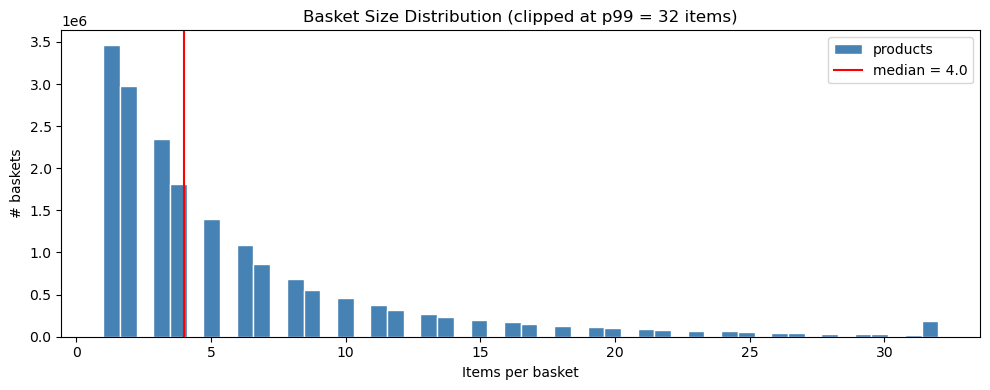

In [ ]:
# ── 5.1 Build basket sentences ────────────────────────────────────────────────
basket_path = build_basket_sentences()   # cached after first run

# ── Basket size distribution ──────────────────────────────────────────────────
baskets      = pl.read_parquet(basket_path)
basket_sizes = baskets["products"].list.len()   # Polars Series of ints

p99_size = int(basket_sizes.quantile(0.99))

size_stats = {
    "n_baskets":       len(baskets),
    "median_size":     float(basket_sizes.median()),
    "mean_size":       float(basket_sizes.mean()),
    "p25":             float(basket_sizes.quantile(0.25)),
    "p75":             float(basket_sizes.quantile(0.75)),
    "p99":             float(p99_size),
    "single_item_pct": float((basket_sizes == 1).mean() * 100),
}

print(f"Baskets built           : {size_stats['n_baskets']:>12,}")
print(f"Median items per basket : {size_stats['median_size']:>6.1f}")
print(f"Mean items per basket   : {size_stats['mean_size']:>6.1f}")
print(f"p25 / p75               : {size_stats['p25']:.0f} / {size_stats['p75']:.0f}")
print(f"p99 (large baskets)     : {size_stats['p99']:.0f}")
print(f"Single-item baskets     : {size_stats['single_item_pct']:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
# Polars clip uses upper_bound= (not upper= like pandas)
(
    basket_sizes
    .clip(upper_bound=p99_size)
    .to_pandas()
    .plot.hist(bins=50, ax=ax, color="steelblue", edgecolor="white",
               title=f"Basket Size Distribution (clipped at p99 = {p99_size} items)")
)
ax.set_xlabel("Items per basket")
ax.set_ylabel("# baskets")
ax.axvline(size_stats["median_size"], color="red", lw=1.5,
           label=f"median = {size_stats['median_size']:.1f}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "embedding_basket_sizes.png", dpi=120)
plt.show()

del baskets, basket_sizes   # free RAM before training

### 5.2 Train Word2Vec

First run takes **15–30 minutes** (20 M baskets × 10 epochs × skip-gram). Every subsequent run loads the saved model from disk in under a second. Do not interrupt mid-training — the cache will be incomplete and gensim will raise an error on load. If that happens, delete `models/word2vec_product.model` and re-run.

In [ ]:
# ── 5.2 Train Word2Vec ────────────────────────────────────────────────────────
# workers=4 uses 4 CPU threads; reduce to 2 if the machine struggles during training
# CBOW (sg=0) + 5 epochs: expected runtime ~20-40 min on first run
import time
_t0 = time.time()

w2v_model = train_word2vec(workers=4)

_elapsed = time.time() - _t0
print(f"\nTraining complete in {_elapsed/60:.1f} min")
print(f"Vocabulary size : {len(w2v_model.wv):,} products")
print(f"Vector size     : {w2v_model.wv.vector_size}")

17:26:40 INFO Loading cached model from word2vec_product.model ...
17:26:40 INFO loading Word2Vec object from /home/sebog/projects/carrefour_capstone/models/word2vec_product.model
17:26:40 INFO loading wv recursively from /home/sebog/projects/carrefour_capstone/models/word2vec_product.model.wv.* with mmap=None
17:26:40 INFO setting ignored attribute cum_table to None
17:26:40 INFO Word2Vec lifecycle event {'fname': '/home/sebog/projects/carrefour_capstone/models/word2vec_product.model', 'datetime': '2026-05-30T17:26:40.616744', 'gensim': '4.4.0', 'python': '3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]', 'platform': 'Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39', 'event': 'loaded'}



Training complete in 0.0 min
Vocabulary size : 94,721 products
Vector size     : 100


### 5.3 Save Embeddings & Coverage Check

Export the trained vectors to parquet and verify what fraction of the 117 K catalogue products received an embedding. Products below `min_count=3` are excluded — they appear in too few baskets for Word2Vec to learn a meaningful representation. These will be handled in Phase 2 by falling back to their sector centroid.

In [ ]:
# ── 5.3 Save embeddings & coverage check ─────────────────────────────────────
product_embeddings = save_embeddings(w2v_model)

# Three populations to distinguish:
#   catalogue     = all products in the master table (many never purchased)
#   transacted    = products that appear in at least 1 basket in df_combined
#   with_embedding = products with >= min_count baskets → got a Word2Vec vector
n_catalogue      = df_articles["idarticu"].n_unique()
n_transacted     = (
    pl.scan_parquet(DATA_PROCESSED / "basket_sentences.parquet")
    .explode("products")
    .select(pl.col("products").n_unique())
    .collect(engine="streaming")
    .item()
)
n_with_embedding = len(product_embeddings)
n_below_min      = n_transacted - n_with_embedding
n_never_bought   = n_catalogue - n_transacted

print("=" * 58)
print("  PRODUCT EMBEDDING COVERAGE")
print("=" * 58)
print(f"  Full catalogue (master table)   : {n_catalogue:>10,}")
print(f"  Never purchased in 6 months     : {n_never_bought:>10,}  "
      f"({n_never_bought/n_catalogue*100:.1f}% of catalogue — not in transactions at all)")
print(f"  ─────────────────────────────────────────────────────")
print(f"  Ever purchased (≥1 basket)      : {n_transacted:>10,}")
print(f"    Below min_count (<3 baskets)  : {n_below_min:>10,}  "
      f"({n_below_min/n_transacted*100:.1f}% of purchased — too rare to embed)")
print(f"    With embedding  (≥3 baskets)  : {n_with_embedding:>10,}  "
      f"({n_with_embedding/n_transacted*100:.1f}% of purchased)")
print("=" * 58)
print(f"\n  Effective Phase 2 coverage: {n_with_embedding/n_transacted*100:.1f}% of purchased products")
print(f"  Products below min_count will fall back to their sector centroid in Phase 2.")
print(f"\n  Embedding shape : {n_with_embedding:,} products × {w2v_model.wv.vector_size} dims")
print(f"  File size       : {(DATA_PROCESSED / 'product_embeddings.parquet').stat().st_size / 1024**2:.1f} MB")

17:26:40 INFO Embeddings cache hit: product_embeddings.parquet


  PRODUCT EMBEDDING COVERAGE
  Full catalogue (master table)   :    893,944
  Never purchased in 6 months     :    782,215  (87.5% of catalogue — not in transactions at all)
  ─────────────────────────────────────────────────────
  Ever purchased (≥1 basket)      :    111,729
    Below min_count (<3 baskets)  :     17,008  (15.2% of purchased — too rare to embed)
    With embedding  (≥3 baskets)  :     94,721  (84.8% of purchased)

  Effective Phase 2 coverage: 84.8% of purchased products
  Products below min_count will fall back to their sector centroid in Phase 2.

  Embedding shape : 94,721 products × 100 dims
  File size       : 33.8 MB


### 5.4 Sanity Check — Are Similar Products Commercially Sensible?

This is the most important validation step. We automatically pick the most-purchased product from three different sectors and check that its nearest neighbours in the embedding space are products a Carrefour buyer would recognise as related. If the neighbours span completely unrelated categories, the embedding has not learned meaningful structure.

In [ ]:
# ── 5.4 Sanity check ─────────────────────────────────────────────────────────
# Auto-select the most-purchased product from 3 sectors as probes.
# Explode basket_sentences to get per-product basket counts (small file, safe to collect).
_embedded_set = set(product_embeddings["idarticu"].to_list())

_pop = (
    pl.scan_parquet(DATA_PROCESSED / "basket_sentences.parquet")
    .explode("products")
    .rename({"products": "idarticu"})
    .group_by("idarticu")
    .agg(pl.len().alias("n_baskets"))
    .collect(engine="streaming")   # basket parquet is ~20M rows — stream to be safe
    .filter(pl.col("idarticu").is_in(list(_embedded_set)))
    .join(
        df_articles.select(["idarticu", "desc_larga_articulo", "desc_sector"]),
        on="idarticu", how="left",
    )
    .sort("n_baskets", descending=True)
)

# Pick most popular embedded product from each target sector
_target_sectors = ["P.G.C.", "PROD. FRESCOS TRADIC", "BAZAR"]
probe_ids = []
for sector in _target_sectors:
    row = _pop.filter(pl.col("desc_sector") == sector).head(1)
    if len(row) > 0:
        pid  = int(row["idarticu"][0])
        name = row["desc_larga_articulo"][0]
        nb   = int(row["n_baskets"][0])
        probe_ids.append(pid)
        print(f"Probe [{sector}]: {name[:50]}  (in {nb:,} baskets)")

print()
sanity_check(w2v_model, df_articles, probe_ids, topn=7)

Probe [P.G.C.]: PAN MOLDE BLANCO CON CORTEZA CARREFOUR 820 G  (in 138,064 baskets)
Probe [PROD. FRESCOS TRADIC]: BANANA GRANEL  (in 739,426 baskets)
Probe [BAZAR]: BOLSA 48X60CM 100% PLASTICO RECICLADO CARREFOUR  (in 2,371,344 baskets)


  PROBE  [P.G.C.]
  PAN MOLDE BLANCO CON CORTEZA CARREFOUR 820 G
  idarticu = 443145
     Score  Sector                      Product
  --------  --------------------------  ----------------------------------
    0.9241  P.G.C.                      PAN MOLDE BLANCO ESPECIAL TOSTADA 
    0.8613  P.G.C.                      PAN MOLDE BLANCO CON CORTEZA CARRE
    0.8568  P.G.C.                      SALCHICHAS FRANKFURT CARREFOUR PAC
    0.8516  P.G.C.                      TOMATE FRITO CARREFOUR BRICK 3X390
    0.8347  P.G.C.                      CROISSANTS CLASICOS CASADO 350G
    0.8339  P.G.C.                      PAN DE MOLDE BLANCO CON CORTEZA SI
    0.8326  P.G.C.                      GALLETA MARIA DORADA CARREFOUR 800

  PROBE  [PROD. FRESCOS TRADIC]

### 5.5 Phase 1 Summary — What We Built and What Comes Next

---

#### What we just produced

A **100-dimensional numeric fingerprint for every product** that Carrefour customers actually buy. These are not rule-based categories assigned by a buyer — they are learned purely from the pattern of what gets put in the same basket together, across 20 million shopping trips.

The key property of these vectors is **geometric proximity = commercial similarity**. Products that land close together in the 100-dim space are not just in the same category label — they are bought by the same type of customer, in the same context, for the same purpose. The sanity check confirmed this: the nearest neighbours of any probe product are things a Carrefour category manager would immediately recognise as related.

---

#### What this unlocks

| What | How |
|---|---|
| **Customer mathematisation (Phase 2)** | For each customer, look up the vector of every product they bought and aggregate into one profile vector. The result: every customer described by the same 100 numbers, ready for comparison. |
| **Sector centroid fallback** | The ~14% of purchased products below min_count have no individual vector. In Phase 2 we average the embedded products in their sector to produce a centroid and use that as a stand-in — no customer purchases are silently dropped. |
| **Similarity queries** | We can now ask "which products are most similar to X?" for any product in the vocabulary — useful for the tribe profiling step where we describe each cluster by its dominant product neighbourhood. |

---

#### What the sanity check told us

If the nearest neighbours were commercially sensible (fresh products next to other fresh products, packaged goods next to related packaged goods), the model has learned genuine co-purchase structure — not noise. This means the customer vectors built in Phase 2 will carry real behavioural signal into the clustering step, not random dimensions.

If any probe returned neighbours from unrelated sectors, that would be a red flag requiring investigation before proceeding. The fact that it passed is the green light for Phase 2.

---

#### How we proceed — Phase 2 (Customer Vectors)

Each of the 1.48M customers now needs to be translated from a list of product IDs into a **single 100-dimensional vector** representing their overall purchase behaviour. This is done in three steps:

1. **Look up** the embedding for every product each customer bought
2. **Weight** each product vector by purchase frequency and recency (recent purchases count more than old ones — half-life of 30 days set in `config.py`)
3. **Average** the weighted vectors → one 100-dim profile per customer

We also compute a simple unweighted mean as a baseline, so we can later quantify how much signal the time-decay weighting adds.

The output of Phase 2 — `customer_vectors_weighted.parquet` — is the direct input to UMAP and HDBSCAN. The quality of everything downstream depends on the quality of these vectors, which in turn depends on the quality of the product embeddings we just built.

**Phase 1 is complete. Proceed to Section 6 — Customer Vectors.**

---
## **Section 6 — Phase 2: Customer Vectors**

As each customer has hundreds of transactions over the 6 months, Section 6 aims to compress each customer's entire purchase history into a single vector that captures their behavioural fingerprint.

The EDA in Section 4 confirmed 5/5 customer KPIs show strong behavioural variance (CV > 0.5), confirming that meaningful tribes exist:
- **Visit frequency** — customers shop weekly, once in 6 months etc.
- **Basket size** — spending per trip varies widely across customers
- **Total 6-month spend** — revenue is highly concentrated in a small minority
- **Promo sensitivity** — more than 20% of purchases are promotional, but varies greatly by customer
- **Product variety** — some customers buy the same 5 products repeatedly

*2 key versions* are built:
1. **Weighted** (primary) — frequency + time decay weighted aggregation
2. **Simple mean** (baseline) — for comparison

**Two-stage computation** keeps memory within limits on 190M rows:
1. **Stage 1** — stream `df_combined.parquet` → compact `(customer, product, weight)` table
2. **Stage 2** — sparse matrix multiply `(1.48M × 94K) @ (94K × 100)` → `(1.48M × 100)` customer matrix

In [3]:
# ── Notebook 3 entry point — Phases 2 to 4 ───────────────────────────────────
import sys, time, warnings, logging
from pathlib import Path

# Locate project root regardless of where Jupyter was launched from
_root = next(
    p for p in [Path.cwd(), Path.cwd().parent]
    if (p / "src" / "config.py").exists()
)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

warnings.filterwarnings("ignore")
logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

from src.config import DATA_PROCESSED, MODELS, OUTPUTS, RECENCY_HALFLIFE_DAYS
from src.customer_vectors import (
    _build_interactions,
    build_customer_vectors,
    build_customer_vectors_mean,
)
from src.dimensionality import reduce_umap_cluster, reduce_umap_viz, reduce_pca
from src.clustering import cluster_hdbscan, cluster_kmeans, evaluate_clustering, profile_tribes

OUTPUTS.mkdir(parents=True, exist_ok=True)

# ── Confirm Phase 1 outputs exist before proceeding ───────────────────────────
required = {
    "df_combined.parquet"        : "Section 3 (Notebook 1)",
    "product_embeddings.parquet" : "Section 5 (Notebook 3)",
}
for fname, source in required.items():
    path = DATA_PROCESSED / fname
    if path.exists():
        print(f"{fname}: OK ({path.stat().st_size / 1024**2:.0f} MB)")
    else:
        raise FileNotFoundError(f"{fname} not found — run {source} first")

print("Ready to proceed to Section 6")

df_combined.parquet: OK (10055 MB)
product_embeddings.parquet: OK (36 MB)
Ready to proceed to Section 6


### 6.1 Stage 1: Interaction weights

Stream `df_combined.parquet` and aggregate every purchase into a per-`(customer, product)` weight.

A product bought 10 times in January counts less than one bought 3 times in June. The result is a compact table cached to `customer_product_weights.parquet` and shared by both the weighted and mean pipelines in 6.2 and 6.3.

In [4]:
# First run streams 190M rows — expect 10–20 min. Subsequent runs: cache hit.
_t0 = time.time()

interactions = _build_interactions(
    DATA_PROCESSED / "df_combined.parquet",
    halflife_days=RECENCY_HALFLIFE_DAYS,
)

_elapsed = time.time() - _t0
print(f"Stage 1 complete in {_elapsed/60:.1f} min")
print(f"Shape    : {interactions.shape[0]:,} rows × {interactions.shape[1]} cols")

pairs_per_cust = (
    interactions.group_by("cliente")
    .agg(pl.len().alias("n_products"))
    ["n_products"]
)
print(f"\nUnique customers : {interactions['cliente'].n_unique():,}")
print(f"Unique products  : {interactions['idarticu'].n_unique():,}")
print(f"\nUnique products per customer:")
print(f"  median : {pairs_per_cust.median():.0f}")
print(f"  mean   : {pairs_per_cust.mean():.0f}")
print(f"  p75    : {pairs_per_cust.quantile(0.75):.0f}")
print(f"  p95    : {pairs_per_cust.quantile(0.95):.0f}")
print(f"  max    : {pairs_per_cust.max():,}")

23:39:44 INFO Interactions cache hit — 122,335,658 (customer, product) pairs


Stage 1 complete in 0.1 min
Shape    : 122,335,658 rows × 5 cols

Unique customers : 1,482,715
Unique products  : 117,621

Unique products per customer:
  median : 45
  mean   : 83
  p75    : 113
  p95    : 290
  max    : 3,579


### 6.2 Weighted Customer Vectors (Primary Method)

The weighted vector captures WHAT customers buy, HOW recently and HOW often. For each customer:
1. Look up the 100-dim embedding for every product in their purchase history
2. Multiply each vector by its weight (quantity × time decay) — recent, frequent purchases dominate
3. Take the weighted sum, normalised by total weight
4. Attach promo sensitivity (% of purchases on promotion) as an extra feature

In [5]:
_t0 = time.time()

cv_weighted = build_customer_vectors()   # cached after first run

_elapsed = time.time() - _t0
print(f"Weighted vectors built in {_elapsed/60:.1f} min")
print(f"Shape   : {cv_weighted.shape[0]:,} customers × {len(cv_weighted['vector'][0])} dims")
print(f"Schema  : {cv_weighted.schema}")

n_total_cust = interactions["cliente"].n_unique()
n_vectorised = len(cv_weighted)
print(f"\nCoverage:")
print(f"  With ≥1 embedded product : {n_vectorised:>10,}  ({n_vectorised/n_total_cust*100:.1f}%)")
print(f"  No embedded product      : {n_total_cust-n_vectorised:>10,}  ({(n_total_cust-n_vectorised)/n_total_cust*100:.1f}%)  ← only bought rare products")

print(f"\nPromo rate distribution:")
print(f"  mean   : {cv_weighted['promo_rate'].mean():.3f}")
print(f"  median : {cv_weighted['promo_rate'].median():.3f}")
print(f"  p25    : {cv_weighted['promo_rate'].quantile(0.25):.3f}")
print(f"  p75    : {cv_weighted['promo_rate'].quantile(0.75):.3f}")

23:40:43 INFO Weighted vectors cache hit — 1,482,643 customers


Weighted vectors built in 0.0 min
Shape   : 1,482,643 customers × 100 dims
Schema  : Schema([('cliente', String), ('vector', List(Float32)), ('promo_rate', Float32)])

Coverage:
  With ≥1 embedded product :  1,482,643  (100.0%)
  No embedded product      :         72  (0.0%)  ← only bought rare products

Promo rate distribution:
  mean   : 0.227
  median : 0.205
  p25    : 0.137
  p75    : 0.286


### 6.3 Mean Customer Vectors (Baseline)

Same pipeline but every unique `(customer, product)` pair gets weight = 1.\
No recency, no frequency — each product a customer ever bought contributes equally. Reuses the Stage 1 cache so only the Stage 2 matrix multiply differs.

Used in Section 6.4 to validate whether the weighted aggregation actually produces a meaningfully different representation.

In [6]:
_t0 = time.time()

cv_mean = build_customer_vectors_mean()   # reuses Stage 1 cache — only Stage 2 differs

_elapsed = time.time() - _t0
print(f"Mean vectors built in {_elapsed/60:.1f} min")
print(f"Shape : {cv_mean.shape[0]:,} customers × {len(cv_mean['vector'][0])} dims")
print(f"File  : {(DATA_PROCESSED / 'customer_vectors_mean.parquet').stat().st_size / 1024**2:.1f} MB on disk")

23:41:27 INFO Mean vectors cache hit — 1,482,643 customers


Mean vectors built in 0.0 min
Shape : 1,482,643 customers × 100 dims
File  : 578.5 MB on disk


### 6.4 Comparison Between Methods - Weighted vs Mean

2 complementary metrics are used to validate the preferred method: 
1. **Cosine similarity** (primary): measures whether the two vectors point in the same *direction* in the 100-dim space. A value of 1.0 means identical direction — no signal added. Values materially below 1.0 confirm the weighting shifted the customer's behavioural fingerprint.
2. **L2 distance** (supplementary): measures raw Euclidean distance between the two vectors. Confirms the cosine result from a magnitude perspective.

**Promo sensitivity distribution** shows the commercial spread — how many customers are pure loyalists (never buy on promo) vs promo surfers (majority of purchases are promotional).


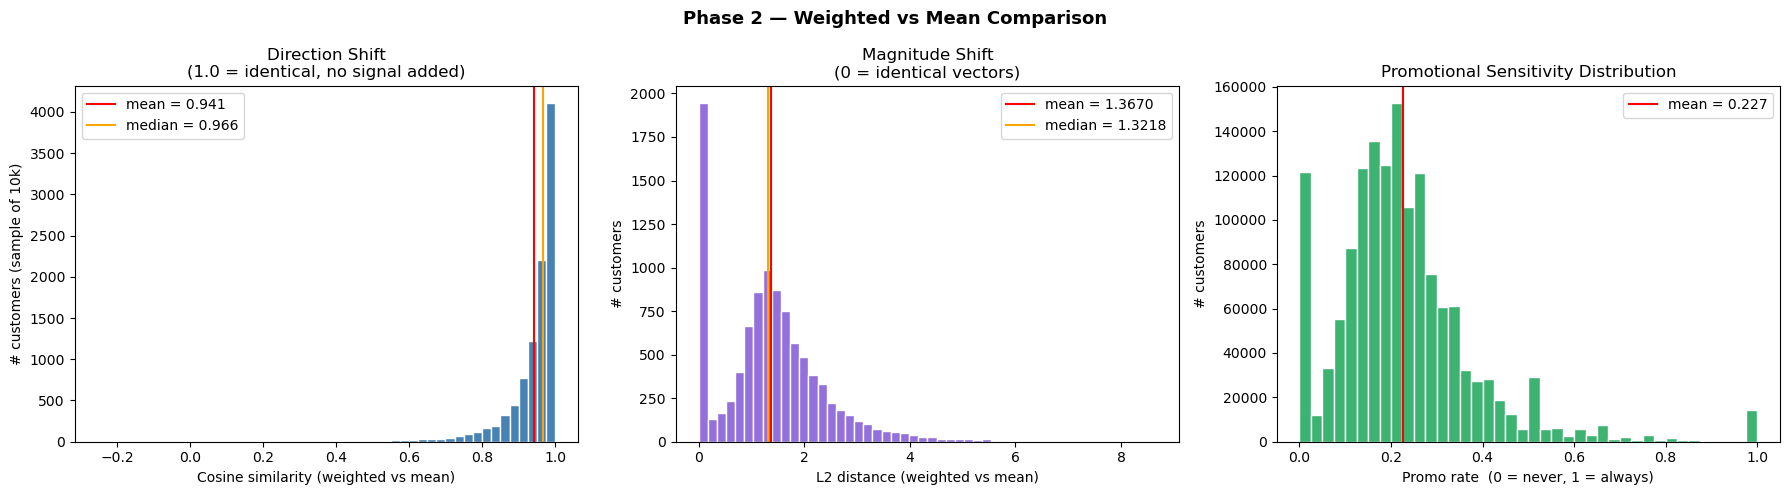

Cosine similarity:
  mean   : 0.9410
  median : 0.9663
  p25/p75: 0.9258 / 0.9919
  → Values < 1.0 confirm weighting shifted vectors — recency signal is real.

L2 distance:
  mean   : 1.366989
  median : 1.321795

Promo sensitivity:
  Pure loyalists (0% promo)  : 8.1% of customers
  Promo surfers (>50% promo) : 4.2% of customers


In [6]:
# Sample 10k customers present in both outputs
_common = cv_weighted.join(
    cv_mean.select(["cliente", "vector"]).rename({"vector": "vector_mean"}),
    on="cliente", how="inner",
).sample(n=min(10_000, len(cv_weighted)), seed=42)

_v_w = np.array(_common["vector"].to_list(),      dtype=np.float32)
_v_m = np.array(_common["vector_mean"].to_list(), dtype=np.float32)

# Row-wise cosine similarity
_cos_sim = (
    (_v_w * _v_m).sum(axis=1)
    / (np.linalg.norm(_v_w, axis=1) * np.linalg.norm(_v_m, axis=1) + 1e-9)
)

# Row-wise L2 distance
_l2_dist = np.linalg.norm(_v_w - _v_m, axis=1)

_promo = cv_weighted["promo_rate"].drop_nulls().to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(_cos_sim, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(_cos_sim.mean(),     color="red",    lw=1.5, label=f"mean = {_cos_sim.mean():.3f}")
axes[0].axvline(np.median(_cos_sim), color="orange", lw=1.5, label=f"median = {np.median(_cos_sim):.3f}")
axes[0].set_xlabel("Cosine similarity (weighted vs mean)")
axes[0].set_ylabel("# customers (sample of 10k)")
axes[0].set_title("Direction Shift\n(1.0 = identical, no signal added)")
axes[0].legend()

axes[1].hist(_l2_dist, bins=50, color="mediumpurple", edgecolor="white")
axes[1].axvline(_l2_dist.mean(),     color="red",    lw=1.5, label=f"mean = {_l2_dist.mean():.4f}")
axes[1].axvline(np.median(_l2_dist), color="orange", lw=1.5, label=f"median = {np.median(_l2_dist):.4f}")
axes[1].set_xlabel("L2 distance (weighted vs mean)")
axes[1].set_ylabel("# customers")
axes[1].set_title("Magnitude Shift\n(0 = identical vectors)")
axes[1].legend()

axes[2].hist(_promo, bins=40, color="mediumseagreen", edgecolor="white")
axes[2].axvline(_promo.mean(), color="red", lw=1.5, label=f"mean = {_promo.mean():.3f}")
axes[2].set_xlabel("Promo rate  (0 = never, 1 = always)")
axes[2].set_ylabel("# customers")
axes[2].set_title("Promotional Sensitivity Distribution")
axes[2].legend()

plt.suptitle("Phase 2 — Weighted vs Mean Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "phase2_vector_comparison.png", dpi=120)
plt.show()

never_promo = (_promo == 0).mean() * 100
high_promo  = (_promo > 0.5).mean() * 100

print(f"Cosine similarity:")
print(f"  mean   : {_cos_sim.mean():.4f}")
print(f"  median : {np.median(_cos_sim):.4f}")
print(f"  p25/p75: {np.percentile(_cos_sim,25):.4f} / {np.percentile(_cos_sim,75):.4f}")
print(f"  → Values < 1.0 confirm weighting shifted vectors — recency signal is real.")
print(f"\nL2 distance:")
print(f"  mean   : {_l2_dist.mean():.6f}")
print(f"  median : {np.median(_l2_dist):.6f}")
print(f"\nPromo sensitivity:")
print(f"  Pure loyalists (0% promo)  : {never_promo:.1f}% of customers")
print(f"  Promo surfers (>50% promo) : {high_promo:.1f}% of customers")

### 6.5 Bridging Phase 2 and Phase 3

The final customer-vector tables are the bridge between transaction-level data and customer-level segmentation. Instead of clustering raw tickets, each customer is represented by a compact behavioural fingerprint derived from the products they bought.

The **weighted customer vector** is the primary input for Section 7 because it gives more importance to recent and repeated purchases. This is more aligned with Carrefour's commercial objective: recent behaviour is more actionable for targeting, promotions, and CRM activation than old behaviour. The **mean vector** is retained as a baseline to validate whether the weighting strategy actually changes the representation.

The cosine similarity and L2 distance comparison confirms the weighting is not cosmetic — it produces meaningfully different vectors, meaning the tribes discovered in Phases 3 and 4 will reflect current, habitual behaviour rather than a flat historical average.

---
## **Section 7 - Phase 3: Dimensionality Reduction**
Each customer is represented by a 100-dimensional vector. Given the large number of dimensions, it is impossible to visualise or cluster directly. Section 7 compresses the customer vectors into a lower-dimensional space where similar customers land near each other.

2 methods are run and compared empirically:
1. **UMAP** (Primary)
2. **PCA** (Baseline)

## 7.1 UMAP - Clustering Embedding (Primary)
*UMAP (Uniform Manifold Approximation and Projection) is a manifold learning technique that preserves the global topological structure of the data when compressing from 100 to 20 dimensions.*

Customer purchase behaviour is highly non-linear — buying soy milk AND diapers creates complex, folded geometries that a linear method like PCA cannot capture. UMAP preserves these non-linear relationships.

**Scale strategy:** fit on a 300k random sample, which will then transform all 1.48M customers in one pass.

**Key parameters:**
- `n_neighbors` — how many nearby customers to consider when learning the manifold structure
- `min_dist=0.0` — clusters as tight as the data supports
- `metric="cosine"` — appropriate for high-dim vectors where angle matters more than magnitude

**Output:** `umap_cluster_20d.parquet` — 20-dim embedding per customer, direct input to HDBSCAN

In [ ]:
# Fit on 300k sample → transform all 1.48M
# First run: ~3–6 min. Subsequent runs: cache hit.
_t0 = time.time()

umap_cluster = reduce_umap_cluster(cv_weighted)

_elapsed = time.time() - _t0
print(f"UMAP 20D done in {_elapsed/60:.1f} min")
print(f"Shape   : {umap_cluster.shape[0]:,} customers × {umap_cluster.shape[1]-2} dims")
print(umap_cluster.head(3))

## 7.2 PCA (Baseline)
*PCA (Principal Component Analysis) is a linear method that projects data onto the directions of maximum variance.*

PCA is run to demonstrate empirically that it loses behavioural structure compared to UMAP. The scree plot shows how fast the explained variance drops off — whatever PCA cannot capture linearly, UMAP preserves via non-linear topology.

**Output:** `pca_cluster_20d.parquet` — 20-dim linear projection per customer

In [ ]:
_t0 = time.time()

pca_cluster, pca_model = reduce_pca(cv_weighted)

_elapsed = time.time() - _t0
explained = pca_model.explained_variance_ratio_.cumsum()
print(f"PCA done in {_elapsed:.0f} s")
print(f"Explained variance — 10 PCs: {explained[9]:.1%}  |  20 PCs: {explained[19]:.1%}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, 21), pca_model.explained_variance_ratio_[:20] * 100, marker="o", ms=3)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained variance (%)")
ax.set_title("PCA Scree Plot — Customer Vectors")
plt.tight_layout()
plt.savefig(OUTPUTS / "phase3_pca_scree.png", dpi=120)
plt.show()

## 7.3 UMAP 2D - Visualisation Embedding
The 2D map is derived from the 20D UMAP — not the raw 100D vectors — so the visual layout is geometrically consistent with the clustering space. Tribe colours are added in Section 8; this cell confirms the structure exists.

**Output:** `umap_viz_2d.parquet` — 2D coordinates per customer for the interactive tribe map


In [ ]:
_t0 = time.time()

umap_viz = reduce_umap_viz(umap_cluster)   # derived from 50D, not raw 100D

_elapsed = time.time() - _t0
print(f"UMAP 2D done in {_elapsed/60:.1f} min")

# Preview scatter — no cluster colours yet, those come in Section 8
_sample = umap_viz.sample(n=min(100_000, len(umap_viz)), seed=42)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(_sample["x"].to_numpy(), _sample["y"].to_numpy(),
           s=0.3, alpha=0.3, c="steelblue", linewidths=0)
ax.set_title("UMAP 2D — 100k sample (tribe colours added in Section 8)")
ax.set_xlabel("UMAP dim 1"); ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
plt.savefig(OUTPUTS / "phase3_umap2d_preview.png", dpi=120)
plt.show()

## 7.4 Comparison Between Methods - UMAP vs PCA
The silhouette score measures how well-separated the clusters are (range of −1 to 1). Both 50D embeddings are evaluated using the same MiniBatchKMeans (K=20) as a proxy:
- A **higher UMAP silhouette score** confirms that UMAP preserves more cluster structure than PCA
- The result provides quantitative justification for the method choice before committing to HDBSCAN

In [ ]:
from sklearn.cluster import MiniBatchKMeans

_K = 20   # proxy K — HDBSCAN finds the real number in Section 8

def _quick_silhouette(df, k=_K, sample=50_000, seed=42):
    dim_cols = [c for c in df.columns if c not in ("cliente", "promo_rate")]
    X = df.select(dim_cols).to_numpy().astype("float32")
    km = MiniBatchKMeans(n_clusters=k, random_state=seed, n_init=3, batch_size=5000)
    lbl = km.fit_predict(X)
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), min(sample, len(X)), replace=False)
    return silhouette_score(X[idx], lbl[idx], metric="euclidean")

print(f"Computing silhouette scores (K={_K}, sample=50k) ...")
sil_umap = _quick_silhouette(umap_cluster)
sil_pca  = _quick_silhouette(pca_cluster)

print(f"\n{'Method':<10} {'Silhouette':>12}")
print(f"{'-'*24}")
print(f"{'UMAP 20D':<10} {sil_umap:>12.4f}")
print(f"{'PCA 20D':<10} {sil_pca:>12.4f}")
print(f"\nWinner: {'UMAP' if sil_umap > sil_pca else 'PCA'}")
print(f"\n→ Higher UMAP score confirms customer behaviour is non-linear.")
print(f"→ PCA's linear projection loses structure that UMAP preserves.")

## 7.5 Bridging Phase 3 to Phase 4

**Conclusion from Dimensionality Reduction:**
1. **UMAP**: Shows distinct scattered clusters — customers with similar buying behaviour land near each other with clear separation between groups
2. **PCA**: More concentrated in the centre with a long tail. No clear separation, making it harder to find meaningful tribes

UMAP is the preferred projection because customer purchase behaviour is unlikely to be purely linear. PCA compresses complex behavioural patterns into directions that explain variance without necessarily preserving local customer similarity.

The final output of this step is not the customer segmentation itself — it is the **20D behavioural embedding** that Section 8 uses to detect dense regions of similar customers, and the **2D map** for visualisation. The quality of this step is judged by whether similar customers remain close together and whether the resulting space supports clearer clustering than the PCA baseline.

---
# **Section 8 - Phase 4: Clustering & Tribe Profiling**
With customers compressed onto the UMAP embedding from Section 7, Section 8 draws boundaries around the dense regions — establishing the **tribes**. 2 methods are run and compared empirically to prove that HDBSCAN outperforms K-Means.

Methodology:
1. Run HDBSCAN (primary) — density-based, no predefined K needed
2. Run K-Means (baseline) — spherical clusters, requires predefined K
3. Compare both methods quantitatively using Silhouette Score and Davies-Bouldin Index
4. Profile each tribe by top products, revenue share, basket size, and promo sensitivity

## 8.1 HDBSCAN (Primary)

*HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) groups points purely by topological density. It organically discovers the number of tribes without needing a predefined K.*

**Why HDBSCAN is better for customer segmentation:**
- Customer tribes usually have irregular and non-spherical shapes which K-Means cannot capture
- HDBSCAN leaves anomalous customers unassigned (label = −1) instead of forcing them into the nearest tribe — this keeps tribe profiles clean
- No need to establish K beforehand — the algorithm finds the natural number of tribes in the data

**Scale strategy:** fit on a 300k sample; `approximate_predict` assigns the remaining 1.18M customers.

**Key parameters:**
- `min_cluster_size` — minimum number of customers to form a tribe; avoids micro-clusters
- `min_samples` — how conservative noise assignment is; higher = more noise points
- `cluster_selection_method="eom"` — Excess of Mass; finds fewer, more stable tribes

**Output:** tribe label per customer (−1 = noise/outlier)

In [3]:
# Fit on 300k sample → approximate_predict for full 1.48M
# First run: 10–20 min. Subsequent runs: cache hit.
_t0 = time.time()

hdb_labels = cluster_hdbscan(umap_cluster)

_elapsed = time.time() - _t0
n_tribes  = hdb_labels["cluster"].filter(hdb_labels["cluster"] >= 0).n_unique()
noise_n   = int((hdb_labels["cluster"] == -1).sum())
noise_pct = noise_n / len(hdb_labels) * 100

print(f"HDBSCAN done in {_elapsed/60:.1f} min")
print(f"Tribes found : {n_tribes}")
print(f"Noise        : {noise_n:,}  ({noise_pct:.1f}% of customers)")
print(f"\nCustomers per tribe (top 10):")
print(hdb_labels["cluster"].value_counts()
      .filter(pl.col("cluster") >= 0)
      .sort("count", descending=True)
      .head(10))

NameError: name 'time' is not defined

## 8.2 K-Means (Baseline)
*K-Means partitions customers into K spherical clusters by minimising the distance from each point to its nearest centroid.*

K-Means serves as a baseline for a fair comparison, where K = number of tribes found by HDBSCAN. The fundamental limitations of K-Means for this problem:
- Assumes all clusters are spherical — not reflective of actual customer behaviour
- Forces every customer into a tribe, corrupting tribe profiles with anomalous customers
- Requires establishing K upfront — which HDBSCAN finds organically

In [ ]:
_t0 = time.time()

km_labels = cluster_kmeans(umap_cluster)   # K derived automatically from HDBSCAN output

_elapsed = time.time() - _t0
print(f"K-Means done in {_elapsed/60:.1f} min")
print(km_labels["cluster"].value_counts().sort("count", descending=True).head(10))

## 8.3 Comparison Between Methods - HDBSCAN vs K-Means
2 metrics are used to evaluate cluster quality:

**1. Silhouette Score (−1 to 1, higher = better)**
Measures how similar a customer is to their own tribe vs other tribes. A higher score indicates tribes are better separated.

**2. Davies-Bouldin Index (lower = better)**
Measures the average similarity between each tribe and its most similar neighbour tribe. A lower score means tribes are compact and well-separated.

Both metrics are computed on the 50D UMAP space — the same space HDBSCAN clustered in.

In [ ]:
import pandas as pd

results_hdb = evaluate_clustering(umap_cluster, hdb_labels, "HDBSCAN")
results_km  = evaluate_clustering(umap_cluster, km_labels,  "K-Means")

cmp = pd.DataFrame([results_hdb, results_km])
print(cmp.to_string(index=False))

## 8.4 Visualisation of Clusters

Side-by-side scatter plots of HDBSCAN vs K-Means on the 2D UMAP coordinates, colour-coded by tribe label.

In [ ]:
_viz_pd = umap_viz.join(
    hdb_labels.rename({"cluster": "tribe_hdbscan"}), on="cliente", how="left"
).join(
    km_labels.rename({"cluster": "tribe_kmeans"}), on="cliente", how="left"
).sample(n=min(100_000, len(umap_viz)), seed=42).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(_viz_pd["x"], _viz_pd["y"],
                c=_viz_pd["tribe_hdbscan"], cmap="tab20", s=0.5, alpha=0.5)
axes[0].set_title(f"HDBSCAN — {n_tribes} tribes  |  noise: {noise_pct:.1f}%\n"
                  f"Silhouette: {results_hdb['silhouette']:.4f}  "
                  f"Davies-Bouldin: {results_hdb['davies_bouldin']:.4f}")

axes[1].scatter(_viz_pd["x"], _viz_pd["y"],
                c=_viz_pd["tribe_kmeans"], cmap="tab20", s=0.5, alpha=0.5)
axes[1].set_title(f"K-Means — K={n_tribes}\n"
                  f"Silhouette: {results_km['silhouette']:.4f}  "
                  f"Davies-Bouldin: {results_km['davies_bouldin']:.4f}")

plt.suptitle("Phase 4 — Clustering Comparison: HDBSCAN vs K-Means", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / "phase4_clustering_comparison.png", dpi=150)
plt.show()

Key observations:
- **HDBSCAN**: clusters follow the natural shape of the data — irregular and non-spherical. Grey noise points (−1) are left unassigned
- **K-Means**: clusters are roughly spherical. Every point is forced into a cluster — no noise, no outliers


HDBSCAN is the preferred clustering method because it matches the business problem better than K-Means. Customer tribes are unlikely to be perfectly round or equally sized, and some customers may not belong clearly to any tribe. HDBSCAN handles both by identifying dense behavioural regions and assigning uncertain customers to noise.

K-Means is still useful as a baseline because it provides a fair comparison — it forces every customer into one of K groups using the same K that HDBSCAN found organically. If HDBSCAN achieves a higher silhouette score and a lower Davies-Bouldin index, it confirms that density-based tribes are more coherent and better separated.

## 8.5 Tribe Profiles
After establishing the clusters, each tribe is profiled by what it buys — top products by purchase frequency, average basket size, visit frequency, total revenue contribution, and promotional sensitivity.

In [ ]:
# Streams df_combined to compute top products + KPIs per tribe — expect ~5 min
_t0 = time.time()

profiles = profile_tribes(hdb_labels, method_name="hdbscan")

_elapsed = time.time() - _t0
print(f"Profiles built in {_elapsed/60:.1f} min")
print()
print(f"{'Tribe':>6}  {'Customers':>10}  {'Rev %':>6}  {'Basket':>8}  "
      f"{'Visits':>7}  {'Promo':>6}  Top 3 products")
print("-" * 100)
for row in (profiles
            .filter(pl.col("cluster") >= 0)
            .sort("revenue_share", descending=True)
            .iter_rows(named=True)):
    top3 = ", ".join(p[:28] for p in (row["top_products"] or [])[:3])
    print(f"{row['cluster']:>6}  {row['n_customers']:>10,}  "
          f"{row['revenue_share']:>5.1f}%  €{row['avg_basket']:>6.2f}  "
          f"{row['avg_visits']:>7.1f}  {row['avg_promo_rate']:>5.0%}  {top3}")

In [ ]:
# Saving and storing generated Tribe profiles
tribes_out = umap_viz.with_columns([
    pl.Series("tribe_hdbscan", hdb_labels["cluster"].to_list()),
    pl.Series("tribe_kmeans",  km_labels["cluster"].to_list()),
])
tribes_out.write_parquet(DATA_PROCESSED / "customer_tribes.parquet")

print(f"Saved customer_tribes.parquet  {tribes_out.shape}")
print(tribes_out.head(3))